# NB02 — TF-IDF and Ranked Retrieval
### NLP Workshop Series: From Bag-of-Words to Embeddings
Claude Assisted

---

## Workshop Roadmap

```
┌─────────────────────────────────────────────────────────────────────────┐
│              NLP Workshop: From Bag-of-Words to Embeddings              │
├──────┬──────────────────────────────────────────────┬───────────────────┤
│  NB  │  Title                                       │  Status           │
├──────┼──────────────────────────────────────────────┼───────────────────┤
│  01  │  Text Preprocessing & Bag-of-Words           │  ✓ Completed      │
│  02  │  TF-IDF and Ranked Retrieval                 │  ◄ YOU ARE HERE   │
│  03  │  N-Grams and Context Windows                 │  Coming up        │
│  04  │  Word Co-occurrence and PMI                  │  Coming up        │
│  05  │  Introduction to Word Embeddings (Word2Vec)  │  Coming up        │
│  06  │  Working with Pre-trained Embeddings         │  Coming up        │
│  07  │  Sentence Embeddings and Semantic Search     │  Coming up        │
│  08  │  Putting It All Together: Mini Search Engine │  Coming up        │
└──────┴──────────────────────────────────────────────┴───────────────────┘
```

---

## What We Learned in NB01

In Notebook 1, we established the foundational pipeline for turning raw text into numerical vectors:

- **Preprocessing**: lowercase → remove punctuation → tokenize → remove stopwords → (optional) stemming
- **Vocabulary building**: collect every unique token across all 6,236 verses of the Quran (sahih translation)
- **Bag-of-Words (BoW)**: represent each verse as a sparse vector of raw word counts
- **Cosine similarity**: measure how similar two BoW vectors are, ignoring vector magnitude
- **Basic keyword search**: vectorize a query and rank verses by cosine similarity

BoW gave us a working search engine. But it has a critical flaw we need to fix.

---

## The Problem That Remains

BoW treats **all words equally**. If the word `"said"` appears 2,500+ times across the corpus and the word `"resurrection"` appears only 80 times, BoW assigns them the same importance: 1 count = 1 count.

This means a passage that says *"He said this and said that and said it again"* will score highly for almost **every query** — not because it is semantically relevant, but because it contains a word that is everywhere.

---

## This Notebook's Objectives

By the end of this notebook, you will be able to:

1. Explain **why** raw word counts are a poor representation of word importance
2. Define **Term Frequency (TF)** and **Inverse Document Frequency (IDF)** mathematically
3. **Compute TF-IDF from scratch** in Python without any library
4. Use **scikit-learn's TfidfVectorizer** efficiently on a large corpus
5. Build a **ranked retrieval search engine** using TF-IDF and cosine similarity
6. Compare **BoW vs TF-IDF** results side-by-side on the same queries
7. Articulate the **remaining limitations** of TF-IDF that motivate word embeddings

---
## Section 0: Setup and Data Loading

In [117]:
print("test")

test


In [118]:
# ── Cell 0.1: Install / verify required packages ────────────────────────────
# Run this once if packages are missing. Safe to skip if already installed.
import subprocess, sys

required = ['nltk', 'scikit-learn', 'pandas', 'numpy', 'matplotlib']
for pkg in required:
    try:
        __import__(pkg.replace('-', '_').split('=')[0])
        print(f'  ✓ {pkg}')
    except ImportError:
        print(f'  Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f'  ✓ {pkg} installed')

  ✓ nltk
  Installing scikit-learn...
  ✓ scikit-learn installed
  ✓ pandas
  ✓ numpy
  ✓ matplotlib


In [119]:
# ── Cell 0.2: Core imports ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['font.size'] = 11

import string
import math
import re
from collections import Counter, defaultdict

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Download required NLTK data
for resource in ['punkt', 'stopwords', 'punkt_tab']:
    try:
        nltk.data.find(f'tokenizers/{resource}')
    except LookupError:
        nltk.download(resource, quiet=True)

print('All imports successful.')

All imports successful.


In [120]:
# ── Cell 0.3: Robust CSV loader ───────────────────────────────────────────────
# We try multiple relative paths so this notebook works regardless of where
# Jupyter was launched from.
import os

candidates = [
    '../quran_translations.csv',
    './quran_translations.csv',
    '../../quran_translations.csv',
    '../data/quran_translations.csv',
    './data/quran_translations.csv',
]

df_raw = None
for path in candidates:
    abs_path = os.path.abspath(path)
    if os.path.exists(abs_path):
        df_raw = pd.read_csv(abs_path)
        print(f'Dataset loaded from: {abs_path}')
        print(f'Shape: {df_raw.shape}')
        break

if df_raw is None:
    raise FileNotFoundError(
        'Could not find quran_translations.csv. '
        'Please place it one directory above this notebook or adjust the path.'
    )

# Keep only the columns we need
df = df_raw[['Surah', 'Verse', 'sahih']].copy()
df.dropna(subset=['sahih'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'\nWorking with {len(df):,} verses (Surah, Verse, sahih).')
print('\nFirst 3 verses:')
df.head(3)

Dataset loaded from: d:\Haq Nawaz\Teaching\NLP\BOW-to-Embeddings\quran_translations.csv
Shape: (6236, 18)

Working with 6,236 verses (Surah, Verse, sahih).

First 3 verses:


,Surah,Verse,sahih
0,1,1,"In the name of Allah, the Entirely Merciful, t..."
1,1,2,"[All] praise is [due] to Allah, Lord of the wo..."
2,1,3,"The Entirely Merciful, the Especially Merciful,"


---
## Section 0 (continued): Preprocessing Function

We redefine the same preprocessing pipeline from NB01 here so this notebook can be run **independently**. Students who already completed NB01 will recognise this function.

In [121]:
# ── Cell 0.4: Preprocessing pipeline (same as NB01) ──────────────────────────

ENGLISH_STOPWORDS = set(stopwords.words('english'))
PUNCTUATION_TABLE = str.maketrans('', '', string.punctuation)
STEMMER = PorterStemmer()

def preprocess(text: str, use_stemming: bool = False) -> list:
    """
    Full text preprocessing pipeline.

    Steps:
      1. Lowercase the text
      2. Remove all punctuation
      3. Tokenize using NLTK word_tokenize
      4. Remove English stopwords
      5. (Optional) Apply Porter stemming

    Parameters
    ----------
    text : str
        Raw verse text.
    use_stemming : bool
        If True, apply Porter stemming to every token.

    Returns
    -------
    list of str
        Cleaned and filtered tokens.
    """
    if not isinstance(text, str) or text.strip() == '':
        return []

    # Step 1 – lowercase
    text = text.lower()

    # Step 2 – remove punctuation
    text = text.translate(PUNCTUATION_TABLE)

    # Step 3 – tokenize
    tokens = word_tokenize(text)

    # Step 4 – remove stopwords and single-character tokens
    tokens = [t for t in tokens if t not in ENGLISH_STOPWORDS and len(t) > 1]

    # Step 5 – optional stemming
    if use_stemming:
        tokens = [STEMMER.stem(t) for t in tokens]

    return tokens


# Apply to every verse in the corpus
print('Preprocessing all verses...')
df['processed'] = df['sahih'].apply(lambda x: preprocess(x, use_stemming=False))

print(f'Done. {len(df):,} verses processed.')
print(f'\nExample — Verse 1:1')
print(f'  Original : {df.loc[0, "sahih"]}')
print(f'  Processed: {df.loc[0, "processed"]}')

Preprocessing all verses...
Done. 6,236 verses processed.

Example — Verse 1:1
  Original : In the name of Allah, the Entirely Merciful, the Especially Merciful.
  Processed: ['name', 'allah', 'entirely', 'merciful', 'especially', 'merciful']


---
## Section 1: Problems with Bag-of-Words

### 1.1 Equal Weighting

In Bag-of-Words, every word in the vocabulary is treated with the same importance. A word that appears in **every single document** (like `"said"` in any text corpus) contributes exactly as much as a word that appears in only **2 documents** (like `"camel"`).

This is fundamentally wrong for search. Consider:

| Word | Frequency across corpus | How distinctive is it? |
|---|---|---|
| `said` | 2,500+ verses | Very low — it's everywhere |
| `mercy` | ~300 verses | Moderate |
| `resurrection` | ~80 verses | High — genuinely distinctive |
| `camel` | ~12 verses | Very high — rare topic |

A passage that contains `"said"` and `"camel"` should score much higher for a camel-related query than for a generic query, but BoW gives both words count = 1 and treats them identically.

### 1.2 The Dominance Problem

Let's demonstrate this with a live example.

In [122]:
# ── Cell 1.1: Count how often key words appear across the corpus ──────────────

# Flatten all processed tokens into one big list
all_tokens = [token for verse_tokens in df['processed'] for token in verse_tokens]
token_counts = Counter(all_tokens)

# Words of interest
words_of_interest = ['said', 'lord', 'mercy', 'day', 'resurrection', 'camel', 'patience', 'fire']

print('Word frequency across the entire Quran corpus (sahih translation)')
print('=' * 60)
print(f'{"Word":<20} {"Total occurrences":<22} {"Appears in N verses"}')
print('-' * 60)

for word in words_of_interest:
    total_occ = token_counts.get(word, 0)
    # Count how many verses contain this word at least once
    verse_count = sum(1 for tokens in df['processed'] if word in tokens)
    print(f'{word:<20} {total_occ:<22} {verse_count}')

print('=' * 60)
print(f'\nTotal vocabulary size: {len(token_counts):,} unique tokens')

Word frequency across the entire Quran corpus (sahih translation)
Word                 Total occurrences      Appears in N verses
------------------------------------------------------------
said                 821                    724
lord                 971                    865
mercy                146                    143
day                  497                    454
resurrection         85                     84
camel                2                      2
patience             18                     18
fire                 163                    155

Total vocabulary size: 5,137 unique tokens


In [123]:
# ── Cell 1.2: Build a BoW vector and show the dominance problem ───────────────

# Select a passage that contains 'said' and a rarer word
# We'll pick the first verse where BOTH 'said' and 'resurrection' appear
target_idx = None
for i, tokens in enumerate(df['processed']):
    if 'said' in tokens and 'resurrection' in tokens:
        target_idx = i
        break

if target_idx is None:
    # fallback: just find a verse with 'resurrection'
    for i, tokens in enumerate(df['processed']):
        if 'resurrection' in tokens:
            target_idx = i
            break

print(f'Target verse index: {target_idx}')
print(f'Surah {df.loc[target_idx, "Surah"]}, Verse {df.loc[target_idx, "Verse"]}')
print(f'\nOriginal text:')
print(f'  "{df.loc[target_idx, "sahih"]}"')
print(f'\nProcessed tokens:')
print(f'  {df.loc[target_idx, "processed"]}')

# Build the BoW vector for this verse
target_tokens = df.loc[target_idx, 'processed']
bow_verse = Counter(target_tokens)

print(f'\nBoW counts for selected words:')
for word in words_of_interest:
    count = bow_verse.get(word, 0)
    bar = '█' * count
    print(f'  {word:<20} {count}  {bar}')

Target verse index: 347
Surah 3, Verse 55

Original text:
  "[Mention] when Allah said, "O Jesus, indeed I will take you and raise you to Myself and purify you from those who disbelieve and make those who follow you [in submission to Allah alone] superior to those who disbelieve until the Day of Resurrection. Then to Me is your return, and I will judge between you concerning that in which you used to differ."

Processed tokens:
  ['mention', 'allah', 'said', 'jesus', 'indeed', 'take', 'raise', 'purify', 'disbelieve', 'make', 'follow', 'submission', 'allah', 'alone', 'superior', 'disbelieve', 'day', 'resurrection', 'return', 'judge', 'concerning', 'used', 'differ']

BoW counts for selected words:
  said                 1  █
  lord                 0  
  mercy                0  
  day                  1  █
  resurrection         1  █
  camel                0  
  patience             0  
  fire                 0  


In [124]:
# ── Cell 1.3: Visual demonstration — BoW scores vs two queries ────────────────
# We use CountVectorizer to build BoW, then show cosine similarity for two queries.

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Build a small BoW model on the full corpus
# We join processed tokens back into strings for sklearn
corpus_strings = [' '.join(tokens) for tokens in df['processed']]

bow_vectorizer = CountVectorizer(max_features=5000)
bow_matrix = bow_vectorizer.fit_transform(corpus_strings)

print(f'BoW matrix shape: {bow_matrix.shape}')
print(f'  ({bow_matrix.shape[0]} verses × {bow_matrix.shape[1]} vocabulary terms)\n')

# Query 1: generic — contains common words
query_generic = 'he said unto them'
# Query 2: specific — contains rare words
query_specific = 'day of resurrection'

def bow_search(query, vectorizer, matrix, df, top_k=5):
    """Search using BoW + cosine similarity."""
    processed_q = ' '.join(preprocess(query))
    q_vec = vectorizer.transform([processed_q])
    scores = cosine_similarity(q_vec, matrix).flatten()
    top_indices = scores.argsort()[::-1][:top_k]
    results = []
    for idx in top_indices:
        results.append({
            'idx': idx,
            'Surah': df.loc[idx, 'Surah'],
            'Verse': df.loc[idx, 'Verse'],
            'score': scores[idx],
            'text': df.loc[idx, 'sahih'][:90] + '...'
        })
    return results

print('=== BoW Search Results ===\n')
for query in [query_generic, query_specific]:
    print(f'Query: "{query}"')
    results = bow_search(query, bow_vectorizer, bow_matrix, df)
    for r in results:
        print(f'  [{r["Surah"]}:{r["Verse"]}] score={r["score"]:.4f} | {r["text"]}')
    print()

BoW matrix shape: (6236, 5000)
  (6236 verses × 5000 vocabulary terms)

=== BoW Search Results ===

Query: "he said unto them"
  [75:27] score=0.5000 | And it is said, "Who will cure [him]?"...
  [27:42] score=0.4867 | So when she arrived, it was said [to her], "Is your throne like this?" She said, "[It is] ...
  [51:30] score=0.4714 | They said, "Thus has said your Lord; indeed, He is the Wise, the Knowing."...
  [36:26] score=0.4472 | It was said, "Enter Paradise." He said, "I wish my people could know...
  [15:52] score=0.4472 | When they entered upon him and said, "Peace." [Abraham] said, "Indeed, we are fearful of y...

Query: "day of resurrection"
  [75:6] score=0.8165 | He asks, "When is the Day of Resurrection?"...
  [75:1] score=0.8165 | I swear by the Day of Resurrection...
  [69:15] score=0.8165 | Then on that Day, the Resurrection will occur,...
  [19:95] score=0.7071 | And all of them are coming to Him on the Day of Resurrection alone....
  [23:16] score=0.7071 | Then inde

### Observation

Notice that BoW results for the generic query tend to retrieve verses that contain `"said"` everywhere — not necessarily the most relevant ones. The word `"said"` is so common that it inflates cosine similarity scores across the board.

This is exactly the **equal-weighting problem**. We need a scoring scheme that:
- **Rewards** words that appear frequently **in this document** (they are important to it)
- **Penalises** words that appear in **almost every document** (they are not distinctive)

That is precisely what **TF-IDF** does.

---
## Section 2: TF-IDF Theory

### 2.1 Intuition

Imagine you are trying to describe what makes a particular verse **unique** within the Quran. A word like `"said"` cannot help — it is in almost every verse, so it says nothing distinctive about this one. But a word like `"camel"` or `"resurrection"` tells you something very specific: *this verse is about that topic*.

TF-IDF captures this intuition with two components:

---

### 2.2 Term Frequency (TF)

**Definition**: How often does word `t` appear in document `d`, normalised by document length?

$$\text{TF}(t, d) = \frac{\text{count of } t \text{ in } d}{\text{total words in } d}$$

**Why normalise?** A long document naturally contains more words. Without normalisation, a 50-word verse and a 5-word verse with the same word once would be treated differently. Dividing by document length makes TF comparable across documents.

**Example**: Verse has 20 words. `"mercy"` appears 2 times.
$$\text{TF}(\text{mercy}, d) = \frac{2}{20} = 0.10$$

---

### 2.3 Inverse Document Frequency (IDF)

**Definition**: How rare is word `t` across the entire corpus of `N` documents?

$$\text{IDF}(t) = \log\left(\frac{N}{df(t)}\right)$$

where:
- `N` = total number of documents (6,236 verses)
- `df(t)` = number of documents that contain term `t` at least once
- `log` is usually natural log or log base 10 (sklearn uses natural log)

**Why the logarithm?** Without it, a word in 1 document vs 10 documents would have a ratio of 6236:623 = 10x, but a word in 10 documents vs 100 documents would also be a 10x ratio. The log compresses this so the scale is more meaningful.

**Intuition**:
- `"said"` appears in ~2,500 verses → IDF = log(6236/2500) ≈ **0.92** (low — common word)
- `"resurrection"` appears in ~80 verses → IDF = log(6236/80) ≈ **4.36** (high — rare word)
- `"camel"` appears in ~12 verses → IDF = log(6236/12) ≈ **6.35** (very high — very rare)

---

### 2.4 TF-IDF Score

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

A word gets a **high TF-IDF score** if it:
1. Appears **frequently in this specific document** (high TF), AND
2. Is **rare across the corpus** (high IDF)

A word gets a **low TF-IDF score** if it:
- Appears rarely in this document (low TF), OR
- Appears everywhere in the corpus (low IDF — the IDF factor kills the score)

---

### 2.5 Worked Example — Three Sample Verses

Let's trace through a tiny example with 3 made-up verses:

```
Corpus (N = 3 documents):
  d1: "he said it was good and said it was kind"
  d2: "the day of resurrection is near"
  d3: "he said the dead will rise on the day of resurrection"

Vocabulary: said, merciful, kind, day, resurrection, near, raise, dead

──────────────────────────────────────────────────────────────────────
Step 1: Document Frequency (df) — how many docs contain each word?
  said        → d1, d3              → df = 2
  merciful    → d1                  → df = 1
  kind        → d1                  → df = 1
  day         → d2, d3              → df = 2
  resurrection→ d2, d3              → df = 2
  near        → d2                  → df = 1
  raise       → d3                  → df = 1
  dead        → d3                  → df = 1

Step 2: IDF(t) = log(3 / df(t))
  said         → log(3/2) = 0.405
  merciful     → log(3/1) = 1.099
  kind         → log(3/1) = 1.099
  day          → log(3/2) = 0.405
  resurrection → log(3/2) = 0.405
  near         → log(3/1) = 1.099
  raise        → log(3/1) = 1.099
  dead         → log(3/1) = 1.099

Step 3: TF for d1 = "he said it was good and said it was kind"
  Raw tokens (after stopword removal): said, merciful, said, kind
  Total words = 4
  said      → 2/4 = 0.500
  merciful  → 1/4 = 0.250
  kind      → 1/4 = 0.250

Step 4: TF-IDF for d1
  said      → 0.500 × 0.405 = 0.203  ← LOW despite high TF, because IDF is low
  merciful  → 0.250 × 1.099 = 0.275  ← Higher score
  kind      → 0.250 × 1.099 = 0.275  ← Higher score
──────────────────────────────────────────────────────────────────────
```

Even though `"said"` appears **twice** in d1 and `"merciful"` appears only **once**, their TF-IDF scores are almost equal — because `"said"` is penalised by its low IDF.

---

### 2.6 ASCII Weighting Diagram

```
  Word frequency in THIS document (TF)
  ↑
  │  ██████████  "said"       TF=high, IDF=low  → TF-IDF = MEDIUM/LOW
  │  ████        "merciful"   TF=low,  IDF=high → TF-IDF = MEDIUM/HIGH
  │  ██          "camel"      TF=low,  IDF=very high → TF-IDF = HIGH
  └─────────────────────────────────────────────────────────────────→
                           Rarity across corpus (IDF)

  The WINNER is a word that is BOTH moderately frequent here
  AND rare everywhere else.
```

---
## Section 3: Computing TF-IDF from Scratch

Before using sklearn, let's implement TF-IDF manually so we understand every calculation.

In [125]:
# ── Cell 3.1: Build document frequency table for the whole corpus ─────────────

print('Building document frequency (df) table...')

# df_table[word] = number of verses that contain 'word' at least once
df_table = defaultdict(int)

for verse_tokens in df['processed']:
    # Use a set so each word is counted only once per verse
    unique_tokens = set(verse_tokens)
    for token in unique_tokens:
        df_table[token] += 1

N = len(df)  # total number of documents (verses)

print(f'Total documents (verses): N = {N:,}')
print(f'Vocabulary size: {len(df_table):,} unique tokens')
print()

# Show df and IDF for our words of interest
print(f'{"Word":<20} {"df (# verses)":<18} {"IDF = log(N/df)"}')
print('-' * 55)
for word in words_of_interest:
    df_val = df_table.get(word, 0)
    if df_val > 0:
        idf_val = math.log(N / df_val)
    else:
        idf_val = 0.0  # word not in vocabulary
    print(f'{word:<20} {df_val:<18} {idf_val:.4f}')

Building document frequency (df) table...
Total documents (verses): N = 6,236
Vocabulary size: 5,137 unique tokens

Word                 df (# verses)      IDF = log(N/df)
-------------------------------------------------------
said                 724                2.1533
lord                 865                1.9754
mercy                143                3.7752
day                  454                2.6200
resurrection         84                 4.3073
camel                2                  8.0449
patience             18                 5.8477
fire                 155                3.6947


In [126]:
# ── Cell 3.2: Compute TF for one verse ───────────────────────────────────────

# Pick the same verse we used in Section 1
verse_tokens = df.loc[target_idx, 'processed']
total_words = len(verse_tokens)
word_counts = Counter(verse_tokens)

print(f'Verse {df.loc[target_idx, "Surah"]}:{df.loc[target_idx, "Verse"]}')
print(f'Tokens ({total_words} total): {verse_tokens}')
print()

print(f'{"Word":<20} {"Count":<10} {"TF = count/total"}')
print('-' * 50)
for word in words_of_interest:
    count = word_counts.get(word, 0)
    tf = count / total_words if total_words > 0 else 0.0
    print(f'{word:<20} {count:<10} {tf:.6f}')

Verse 3:55
Tokens (23 total): ['mention', 'allah', 'said', 'jesus', 'indeed', 'take', 'raise', 'purify', 'disbelieve', 'make', 'follow', 'submission', 'allah', 'alone', 'superior', 'disbelieve', 'day', 'resurrection', 'return', 'judge', 'concerning', 'used', 'differ']

Word                 Count      TF = count/total
--------------------------------------------------
said                 1          0.043478
lord                 0          0.000000
mercy                0          0.000000
day                  1          0.043478
resurrection         1          0.043478
camel                0          0.000000
patience             0          0.000000
fire                 0          0.000000


In [127]:
# ── Cell 3.3: Compute TF-IDF for our words in that verse ─────────────────────

print(f'TF-IDF scores for selected words in Verse {df.loc[target_idx, "Surah"]}:{df.loc[target_idx, "Verse"]}')
print('=' * 65)
print(f'{"Word":<20} {"TF":<12} {"IDF":<12} {"TF-IDF":<12} {"Interpretation"}')
print('-' * 65)

for word in words_of_interest:
    count = word_counts.get(word, 0)
    tf = count / total_words if total_words > 0 else 0.0
    df_val = df_table.get(word, 0)
    idf = math.log(N / df_val) if df_val > 0 else 0.0
    tfidf = tf * idf

    # Interpretation
    if count == 0:
        interp = 'not in this verse'
    elif idf < 1.0:
        interp = 'common corpus word (low IDF)'
    elif idf > 4.0:
        interp = 'very distinctive word!'
    else:
        interp = 'moderately distinctive'

    print(f'{word:<20} {tf:<12.6f} {idf:<12.4f} {tfidf:<12.6f} {interp}')

print('=' * 65)
print('\n>>> KEY INSIGHT: "said" may appear in this verse but its TF-IDF')
print('    score is pulled down by its very LOW IDF (it is everywhere).')
print('    Meanwhile "resurrection" or "camel" get HIGH TF-IDF if present.')

TF-IDF scores for selected words in Verse 3:55
Word                 TF           IDF          TF-IDF       Interpretation
-----------------------------------------------------------------
said                 0.043478     2.1533       0.093622     moderately distinctive
lord                 0.000000     1.9754       0.000000     not in this verse
mercy                0.000000     3.7752       0.000000     not in this verse
day                  0.043478     2.6200       0.113913     moderately distinctive
resurrection         0.043478     4.3073       0.187273     very distinctive word!
camel                0.000000     8.0449       0.000000     not in this verse
patience             0.000000     5.8477       0.000000     not in this verse
fire                 0.000000     3.6947       0.000000     not in this verse

>>> KEY INSIGHT: "said" may appear in this verse but its TF-IDF
    score is pulled down by its very LOW IDF (it is everywhere).
    Meanwhile "resurrection" or "camel" get

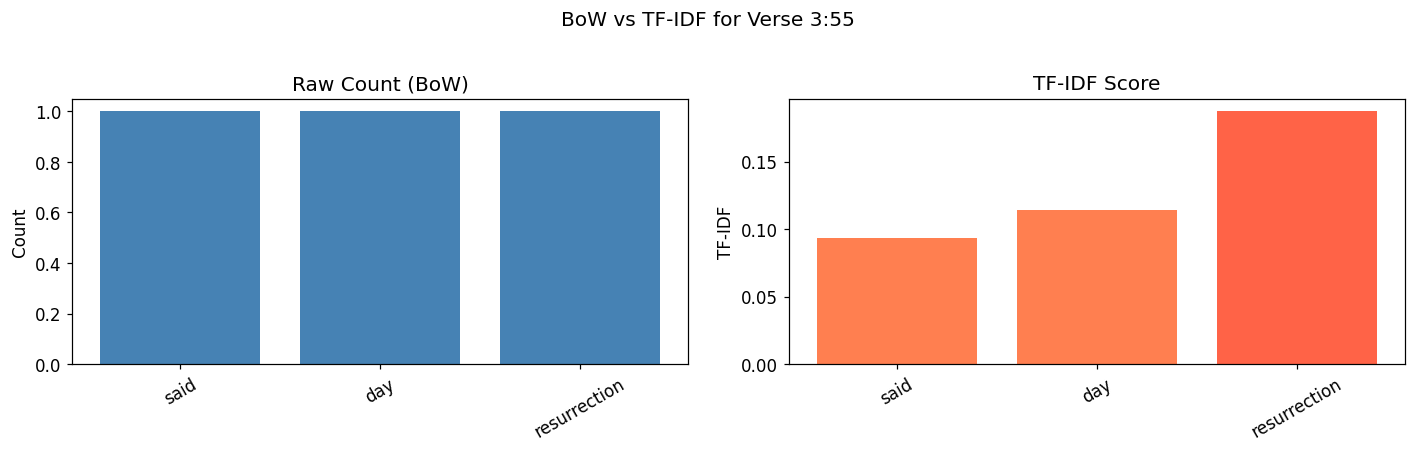

Notice how TF-IDF re-ranks the words compared to raw counts.
Common words shrink; rare words grow.


In [128]:
# ── Cell 3.4: Visualise TF-IDF vs raw count for the selected verse ────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Filter to words that actually appear in this verse
present_words = [w for w in words_of_interest if word_counts.get(w, 0) > 0]
if not present_words:
    # If none of our selected words appear, pick top 8 words in the verse
    present_words = [w for w, _ in word_counts.most_common(8)]

counts_vals = [word_counts.get(w, 0) for w in present_words]
tfidf_vals  = [
    (word_counts.get(w, 0) / total_words) * (math.log(N / df_table[w]) if df_table.get(w, 0) > 0 else 0)
    for w in present_words
]

# Left: raw BoW counts
axes[0].bar(present_words, counts_vals, color='steelblue')
axes[0].set_title('Raw Count (BoW)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# Right: TF-IDF scores
colors = ['tomato' if v == max(tfidf_vals) else 'coral' for v in tfidf_vals]
axes[1].bar(present_words, tfidf_vals, color=colors)
axes[1].set_title('TF-IDF Score')
axes[1].set_ylabel('TF-IDF')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle(f'BoW vs TF-IDF for Verse {df.loc[target_idx, "Surah"]}:{df.loc[target_idx, "Verse"]}', y=1.02)
plt.tight_layout()
plt.show()

print('Notice how TF-IDF re-ranks the words compared to raw counts.')
print('Common words shrink; rare words grow.')

---
## Section 4: TF-IDF with scikit-learn

Our from-scratch implementation is educational, but for the full 6,236-verse corpus we need an efficient implementation. `sklearn.feature_extraction.text.TfidfVectorizer` handles everything.

### Key Parameters

| Parameter | Value | Meaning |
|---|---|---|
| `min_df` | 2 | Ignore words that appear in fewer than 2 verses (typos, noise) |
| `max_features` | 5000 | Keep only the top 5,000 terms by TF score (memory + speed) |
| `smooth_idf` | True | Add 1 to numerator and denominator: IDF = log((1+N)/(1+df)) + 1. Prevents division by zero |
| `sublinear_tf` | True | Replace TF with log(1 + TF). Dampens very long documents |
| `norm` | 'l2' | L2-normalise each row so cosine similarity = dot product |

### Why `sublinear_tf`?

Without `sublinear_tf`, a document with 100 occurrences of a word scores 10× higher than one with 10 occurrences. But is it really 10× more relevant? Probably not — doubling the count should increase relevance, but not linearly.

`sublinear_tf=True` uses **log(1 + count)** instead of raw count:
- count=1  → log(2) = 0.69
- count=2  → log(3) = 1.10 (not 2×)
- count=10 → log(11) = 2.40 (not 10×)

This makes the scoring more robust for long documents.

In [129]:
# ── Cell 4.1: Fit TfidfVectorizer on the full corpus ─────────────────────────

from sklearn.feature_extraction.text import TfidfVectorizer

# We pass pre-processed strings (tokens joined with spaces)
# This way sklearn uses OUR preprocessing, not its own
corpus_strings = [' '.join(tokens) for tokens in df['processed']]

tfidf_vectorizer = TfidfVectorizer(
    min_df=2,           # ignore very rare terms
    max_features=5000,  # top 5000 terms only
    smooth_idf=True,    # add-1 smoothing for IDF
    sublinear_tf=True,  # use log(1+tf) for term frequency
    norm='l2'           # L2-normalise each document vector
)

tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_strings)

print('TF-IDF matrix built successfully.')
print(f'  Shape  : {tfidf_matrix.shape}  ({tfidf_matrix.shape[0]} verses × {tfidf_matrix.shape[1]} terms)')

# Sparsity: fraction of zero entries
total_elements = tfidf_matrix.shape[0] * tfidf_matrix.shape[1]
nonzero = tfidf_matrix.nnz
sparsity = 1.0 - (nonzero / total_elements)
print(f'  Non-zero entries : {nonzero:,}')
print(f'  Total entries    : {total_elements:,}')
print(f'  Sparsity         : {sparsity:.2%}  (most entries are zero)')
print(f'\n  Memory (dense equivalent) would be: {total_elements * 8 / 1e6:.1f} MB')
print(f'  Memory (sparse, actual)   is about: {nonzero * 12 / 1e6:.1f} MB')

TF-IDF matrix built successfully.
  Shape  : (6236, 3240)  (6236 verses × 3240 terms)
  Non-zero entries : 56,584
  Total entries    : 20,204,640
  Sparsity         : 99.72%  (most entries are zero)

  Memory (dense equivalent) would be: 161.6 MB
  Memory (sparse, actual)   is about: 0.7 MB


In [130]:
# Vocabulary match guard
# Both vectorizers must share the same vocabulary for a fair comparison.
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(min_df=2, max_features=5000)
bow_matrix = bow_vectorizer.fit_transform(df['processed'].apply(' '.join))

assert list(bow_vectorizer.get_feature_names_out()) == list(tfidf_vectorizer.get_feature_names_out()), \
    'Vocabulary mismatch! BoW and TF-IDF must use identical settings for a valid comparison.'

print('Vocabulary match confirmed.')
print('BoW  matrix shape :', bow_matrix.shape)
print('TFIDF matrix shape:', tfidf_matrix.shape)
print('Both share the same', bow_matrix.shape[1], 'word vocabulary.')


Vocabulary match confirmed.
BoW  matrix shape : (6236, 3240)
TFIDF matrix shape: (6236, 3240)
Both share the same 3240 word vocabulary.


In [131]:
# ── Cell 4.2: Inspect IDF values — high IDF = rare = distinctive ─────────────

# sklearn stores IDF values in vectorizer.idf_
# vectorizer.get_feature_names_out() gives the vocabulary list
vocab = tfidf_vectorizer.get_feature_names_out()
idf_values = tfidf_vectorizer.idf_

# Create a DataFrame for easy sorting
idf_df = pd.DataFrame({'word': vocab, 'idf': idf_values}).sort_values('idf', ascending=False)

print('TOP 15 HIGHEST IDF words (rarest, most distinctive):')
print('-' * 40)
print(idf_df.head(15).to_string(index=False))

print('\nTOP 15 LOWEST IDF words (most common, least distinctive):')
print('-' * 40)
print(idf_df.tail(15).sort_values('idf').to_string(index=False))

print('\n--- IDF for our words of interest ---')
for word in words_of_interest:
    if word in tfidf_vectorizer.vocabulary_:
        idx = tfidf_vectorizer.vocabulary_[word]
        print(f'  {word:<20} IDF = {idf_values[idx]:.4f}')
    else:
        print(f'  {word:<20} NOT in vocabulary (filtered by min_df or max_features)')

TOP 15 HIGHEST IDF words (rarest, most distinctive):
----------------------------------------
       word      idf
    absence 8.639642
     abused 8.639642
accordingly 8.639642
      lands 8.639642
    lighten 8.639642
       lets 8.639642
     lashes 8.639642
     latter 8.639642
    laughed 8.639642
       lame 8.639642
   likewise 8.639642
   laughing 8.639642
       lays 8.639642
       line 8.639642
    lineage 8.639642

TOP 15 LOWEST IDF words (most common, least distinctive):
----------------------------------------
      word      idf
     allah 2.126412
    indeed 2.513501
      lord 2.974370
      said 3.152083
    people 3.241480
       say 3.265908
      upon 3.448539
       day 3.617957
    except 3.640180
     among 3.683815
     would 3.754318
     earth 3.772108
       one 3.824752
        us 3.877468
punishment 3.933120

--- IDF for our words of interest ---
  said                 IDF = 3.1521
  lord                 IDF = 2.9744
  mercy                IDF = 4.7684
  d

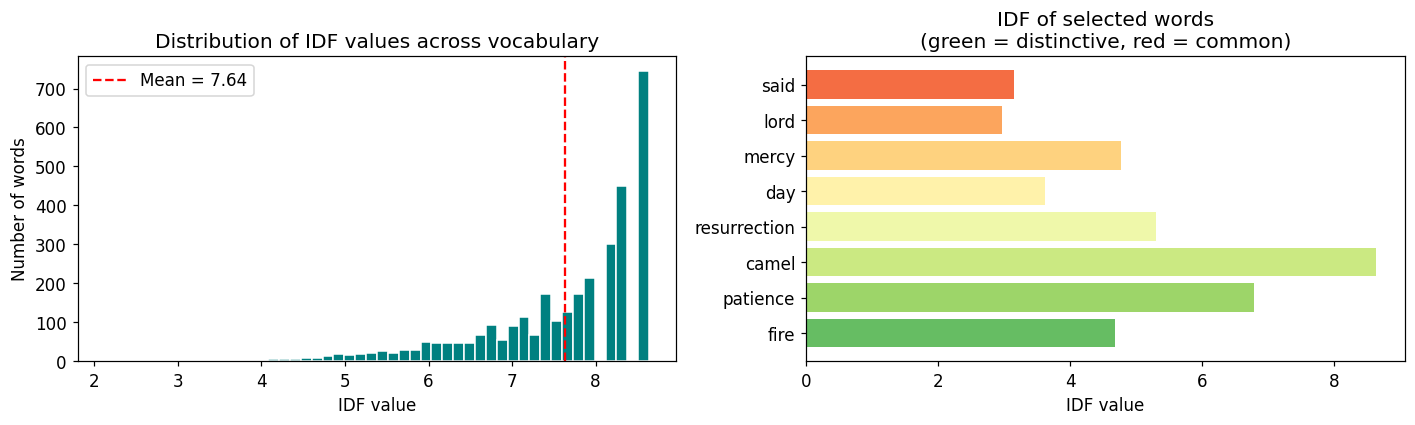

Key insight: the longer the bar, the MORE distinctive the word.
Short bars ("said", "lord") will be DOWN-WEIGHTED in TF-IDF scoring.


In [132]:
# ── Cell 4.3: Visualise IDF distribution ─────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: IDF histogram
axes[0].hist(idf_values, bins=50, color='teal', edgecolor='white')
axes[0].set_xlabel('IDF value')
axes[0].set_ylabel('Number of words')
axes[0].set_title('Distribution of IDF values across vocabulary')
axes[0].axvline(np.mean(idf_values), color='red', linestyle='--', label=f'Mean = {np.mean(idf_values):.2f}')
axes[0].legend()

# Right: IDF bar for our words of interest
woi_present = [(w, idf_values[tfidf_vectorizer.vocabulary_[w]])
               for w in words_of_interest if w in tfidf_vectorizer.vocabulary_]
woi_words, woi_idf = zip(*woi_present) if woi_present else ([], [])

bar_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(woi_words)))
axes[1].barh(woi_words, woi_idf, color=bar_colors)
axes[1].set_xlabel('IDF value')
axes[1].set_title('IDF of selected words\n(green = distinctive, red = common)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print('Key insight: the longer the bar, the MORE distinctive the word.')
print('Short bars ("said", "lord") will be DOWN-WEIGHTED in TF-IDF scoring.')

---
## Section 5: TF-IDF Search Engine

Now let's build a proper search function using our TF-IDF matrix.

In [133]:
# ── Cell 5.1: tfidf_search() function ────────────────────────────────────────

def tfidf_search(query: str, vectorizer, matrix, dataframe, top_k: int = 5) -> pd.DataFrame:
    """
    Search the Quran corpus using TF-IDF + cosine similarity.

    Parameters
    ----------
    query : str
        Raw natural language query (will be preprocessed).
    vectorizer : TfidfVectorizer
        Fitted vectorizer.
    matrix : sparse matrix
        TF-IDF document matrix (n_docs × n_terms).
    dataframe : pd.DataFrame
        Original DataFrame with columns Surah, Verse, sahih.
    top_k : int
        Number of results to return.

    Returns
    -------
    pd.DataFrame
        Top-k results with columns: Surah, Verse, Score, Text.
    """
    # Step 1: preprocess the query using the SAME pipeline as the corpus
    processed_query = ' '.join(preprocess(query))
    print(f'  Preprocessed query: "{processed_query}"')

    # Step 2: vectorize the query using the FITTED vectorizer
    #         (unknown words are silently ignored)
    query_vec = vectorizer.transform([processed_query])

    # Step 3: compute cosine similarity between query and all documents
    #         Since both matrix and query_vec are L2-normalised, cosine sim = dot product
    scores = cosine_similarity(query_vec, matrix).flatten()

    # Step 4: rank by score and take top-k
    top_indices = scores.argsort()[::-1][:top_k]

    results = []
    for rank, idx in enumerate(top_indices, start=1):
        results.append({
            'Rank': rank,
            'Surah': dataframe.loc[idx, 'Surah'],
            'Verse': dataframe.loc[idx, 'Verse'],
            'Score': round(float(scores[idx]), 5),
            'Text': dataframe.loc[idx, 'sahih']
        })

    return pd.DataFrame(results)


print('tfidf_search() defined.')
print('Usage: tfidf_search("your query", tfidf_vectorizer, tfidf_matrix, df)')

tfidf_search() defined.
Usage: tfidf_search("your query", tfidf_vectorizer, tfidf_matrix, df)


In [134]:
# ── Cell 5.2: Query 1 — "allah is merciful" ──────────────────────────────────

print('=' * 70)
print('QUERY 1: "allah is merciful"')
print('=' * 70)
results1 = tfidf_search('allah is merciful', tfidf_vectorizer, tfidf_matrix, df)
print()
for _, row in results1.iterrows():
    print(f"  [{row['Rank']}] Surah {int(row['Surah'])}, Verse {int(row['Verse'])}  | Score: {row['Score']:.5f}")
    print(f"       {row['Text'][:100]}..." if len(row['Text']) > 100 else f"       {row['Text']}")
    print()

QUERY 1: "allah is merciful"
  Preprocessed query: "allah merciful"

  [1] Surah 55, Verse 1  | Score: 0.90718
       The Most Merciful

  [2] Surah 12, Verse 92  | Score: 0.56554
       He said, "No blame will there be upon you today. Allah will forgive you; and He is the most merciful...

  [3] Surah 1, Verse 3  | Score: 0.55968
       The Entirely Merciful, the Especially Merciful,

  [4] Surah 1, Verse 1  | Score: 0.55763
       In the name of Allah, the Entirely Merciful, the Especially Merciful.

  [5] Surah 41, Verse 2  | Score: 0.49560
       [This is] a revelation from the Entirely Merciful, the Especially Merciful -



In [135]:
# ── Cell 5.3: Query 2 — "day of judgement and resurrection" ──────────────────

print('=' * 70)
print('QUERY 2: "day of judgement and resurrection"')
print('=' * 70)
results2 = tfidf_search('day of judgement and resurrection', tfidf_vectorizer, tfidf_matrix, df)
print()
for _, row in results2.iterrows():
    print(f"  [{row['Rank']}] Surah {int(row['Surah'])}, Verse {int(row['Verse'])}  | Score: {row['Score']:.5f}")
    print(f"       {row['Text'][:100]}..." if len(row['Text']) > 100 else f"       {row['Text']}")
    print()

QUERY 2: "day of judgement and resurrection"
  Preprocessed query: "day judgement resurrection"

  [1] Surah 77, Verse 13  | Score: 0.80513
       For the Day of Judgement.

  [2] Surah 77, Verse 14  | Score: 0.60951
       And what can make you know what is the Day of Judgement?

  [3] Surah 78, Verse 17  | Score: 0.50936
       Indeed, the Day of Judgement is an appointed time -

  [4] Surah 44, Verse 40  | Score: 0.50936
       Indeed, the Day of Judgement is the appointed time for them all -

  [5] Surah 75, Verse 1  | Score: 0.50678
       I swear by the Day of Resurrection



In [136]:
# ── Cell 5.4: Query 3 — "patience in hardship" ───────────────────────────────

print('=' * 70)
print('QUERY 3: "patience in hardship"')
print('=' * 70)
results3 = tfidf_search('patience in hardship', tfidf_vectorizer, tfidf_matrix, df)
print()
for _, row in results3.iterrows():
    print(f"  [{row['Rank']}] Surah {int(row['Surah'])}, Verse {int(row['Verse'])}  | Score: {row['Score']:.5f}")
    print(f"       {row['Text'][:100]}..." if len(row['Text']) > 100 else f"       {row['Text']}")
    print()

QUERY 3: "patience in hardship"
  Preprocessed query: "patience hardship"

  [1] Surah 94, Verse 6  | Score: 0.48707
       Indeed, with hardship [will be] ease.

  [2] Surah 94, Verse 5  | Score: 0.48707
       For indeed, with hardship [will be] ease.

  [3] Surah 90, Verse 4  | Score: 0.44530
       We have certainly created man into hardship.

  [4] Surah 18, Verse 67  | Score: 0.43689
       He said, "Indeed, with me you will never be able to have patience.

  [5] Surah 18, Verse 68  | Score: 0.41897
       And how can you have patience for what you do not encompass in knowledge?"



In [137]:
# ── Cell 5.5: Query 4 — charity orphans feeding poor ─────────────────────────
# Better stress-test for TF-IDF: rare words like orphans/poor get high IDF boost.

query4 = 'charity orphans feeding poor'
print('=' * 70)
print('QUERY 4: "charity orphans feeding poor"')
print('Rare words get high IDF boost here.')
print('=' * 70)

results4 = tfidf_search(query4, tfidf_vectorizer, tfidf_matrix, df)
print()
for _, row in results4.iterrows():
    print(f"  [{row['Rank']}] Surah {int(row['Surah'])}, Verse {int(row['Verse'])}  | Score: {row['Score']:.5f}")
    print(f"       {row['Text'][:100]}..." if len(row['Text']) > 100 else f"       {row['Text']}")
    print()

# Show IDF of query words
processed_q4 = preprocess(query4)
vocab    = tfidf_vectorizer.vocabulary_
idf_vals = tfidf_vectorizer.idf_
print('IDF values of query words (higher = rarer = more distinctive):')
print(f'{"Word":<20} {"IDF"}')
print('-' * 30)
for word in processed_q4:
    if word in vocab:
        print(f'{word:<20} {idf_vals[vocab[word]]:.4f}')
    else:
        print(f'{word:<20} not in vocabulary')

QUERY 4: "charity orphans feeding poor"
Rare words get high IDF boost here.
  Preprocessed query: "charity orphans feeding poor"

  [1] Surah 107, Verse 3  | Score: 0.55307
       And does not encourage the feeding of the poor.

  [2] Surah 69, Verse 34  | Score: 0.55307
       Nor did he encourage the feeding of the poor.

  [3] Surah 90, Verse 14  | Score: 0.32128
       Or feeding on a day of severe hunger

  [4] Surah 74, Verse 44  | Score: 0.28077
       Nor did we used to feed the poor.

  [5] Surah 58, Verse 4  | Score: 0.25753
       And he who does not find [a slave] - then a fast for two months consecutively before they touch one ...

IDF values of query words (higher = rarer = more distinctive):
Word                 IDF
------------------------------
charity              7.1733
orphans              7.0992
feeding              7.6588
poor                 6.6472


---
## Section 6: BoW vs TF-IDF Comparison

Let's run the same query through both methods and compare results side by side. This is the most important section for understanding *why* TF-IDF is an improvement.

In [138]:
# ── Cell 6.1: Side-by-side results for the same query ────────────────────────

COMPARISON_QUERY = 'day of judgement and resurrection'

print(f'Comparison query: "{COMPARISON_QUERY}"')
print('Preprocessing:', preprocess(COMPARISON_QUERY))
print()

# --- TF-IDF results ---
print('>>> TF-IDF Search')
tfidf_res = tfidf_search(COMPARISON_QUERY, tfidf_vectorizer, tfidf_matrix, df)

# --- BoW results ---
print('\n>>> BoW Search')
bow_res_rows = bow_search(COMPARISON_QUERY, bow_vectorizer, bow_matrix, df, top_k=5)
bow_df = pd.DataFrame(bow_res_rows)

# Print side-by-side table
print()
print(f'{"Rank":<6} {"--- TF-IDF ---":<50} {"--- BoW ---"}')
print('-' * 110)

for i in range(5):
    trow = tfidf_res.iloc[i]
    brow = bow_res_rows[i]

    t_ref  = f"{int(trow['Surah'])}:{int(trow['Verse'])} (s={trow['Score']:.4f})"
    b_ref  = f"{brow['Surah']}:{brow['Verse']} (s={brow['score']:.4f})"
    t_text = trow['Text'][:40] + '...'
    b_text = brow['text'][:40]

    print(f'{i+1:<6} {t_ref:<18} {t_text:<34} {b_ref:<18} {b_text}')

print()
print('Observation: TF-IDF ranks verses that are SPECIFICALLY about resurrection')
print('higher, even if they mention "said" less. BoW tends to surface generic verses.')

Comparison query: "day of judgement and resurrection"
Preprocessing: ['day', 'judgement', 'resurrection']

>>> TF-IDF Search
  Preprocessed query: "day judgement resurrection"

>>> BoW Search

Rank   --- TF-IDF ---                                     --- BoW ---
--------------------------------------------------------------------------------------------------------------
1      77:13 (s=0.8051)   For the Day of Judgement....       77:13 (s=0.8165)   For the Day of Judgement....
2      77:14 (s=0.6095)   And what can make you know what is the D... 75:6 (s=0.6667)    He asks, "When is the Day of Resurrectio
3      78:17 (s=0.5094)   Indeed, the Day of Judgement is an appoi... 69:15 (s=0.6667)   Then on that Day, the Resurrection will 
4      44:40 (s=0.5094)   Indeed, the Day of Judgement is the appo... 75:1 (s=0.6667)    I swear by the Day of Resurrection...
5      75:1 (s=0.5068)    I swear by the Day of Resurrection... 37:26 (s=0.5774)   But they, that Day, are in surrender....

Obser

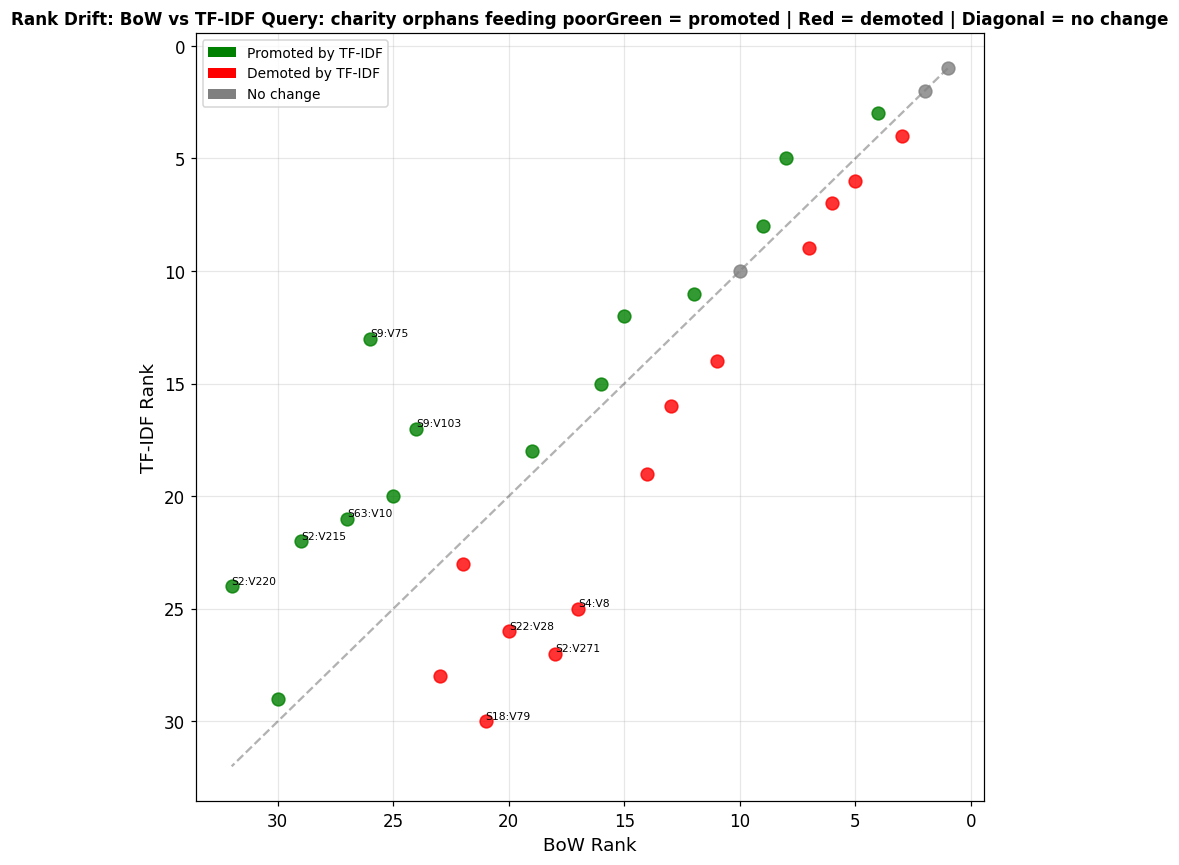

Rank drift plot saved as rank_drift_bow_vs_tfidf.png


In [139]:
# Rank drift scatter plot: BoW rank vs TF-IDF rank for the same query
# Green dots = verses promoted by TF-IDF (rank improved)
# Red dots   = verses demoted  by TF-IDF (rank dropped)
# Diagonal   = no change

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib.patches import Patch

drift_query = 'charity orphans feeding poor'
top_n = 30

proc_q = ' '.join(preprocess(drift_query))
bow_q_vec = bow_vectorizer.transform([proc_q])
bow_scores = cosine_similarity(bow_q_vec, bow_matrix).flatten()

tfidf_q_vec = tfidf_vectorizer.transform([proc_q])
tfidf_scores = cosine_similarity(tfidf_q_vec, tfidf_matrix).flatten()

top_idx = np.argsort(tfidf_scores)[::-1][:top_n]
bow_ranks   = np.argsort(np.argsort(-bow_scores))
tfidf_ranks = np.argsort(np.argsort(-tfidf_scores))

bow_r    = [int(bow_ranks[i])   + 1 for i in top_idx]
tfidf_r  = [int(tfidf_ranks[i]) + 1 for i in top_idx]
labels   = [f"S{int(df.iloc[i]['Surah'])}:V{int(df.iloc[i]['Verse'])}" for i in top_idx]

fig, ax = plt.subplots(figsize=(8, 8))
max_rank = max(max(bow_r), max(tfidf_r))
ax.plot([1, max_rank], [1, max_rank], 'k--', alpha=0.3, label='No change')

for bx, tx, label in zip(bow_r, tfidf_r, labels):
    color = 'green' if tx < bx else ('red' if tx > bx else 'gray')
    ax.scatter(bx, tx, color=color, s=70, alpha=0.8, zorder=3)
    if abs(bx - tx) > 5:
        ax.annotate(label, (bx, tx), fontsize=7, ha='left', va='bottom')

legend_elements = [
    Patch(facecolor='green', label='Promoted by TF-IDF'),
    Patch(facecolor='red',   label='Demoted by TF-IDF'),
    Patch(facecolor='gray',  label='No change'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
ax.set_xlabel('BoW Rank', fontsize=12)
ax.set_ylabel('TF-IDF Rank', fontsize=12)
ax.set_title('Rank Drift: BoW vs TF-IDF Query: ' + drift_query + 'Green = promoted | Red = demoted | Diagonal = no change', fontsize=11, fontweight='bold')
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rank_drift_bow_vs_tfidf.png', dpi=120, bbox_inches='tight')
plt.show()
print('Rank drift plot saved as rank_drift_bow_vs_tfidf.png')

Query tokens after preprocessing: ['day', 'judgement', 'resurrection']


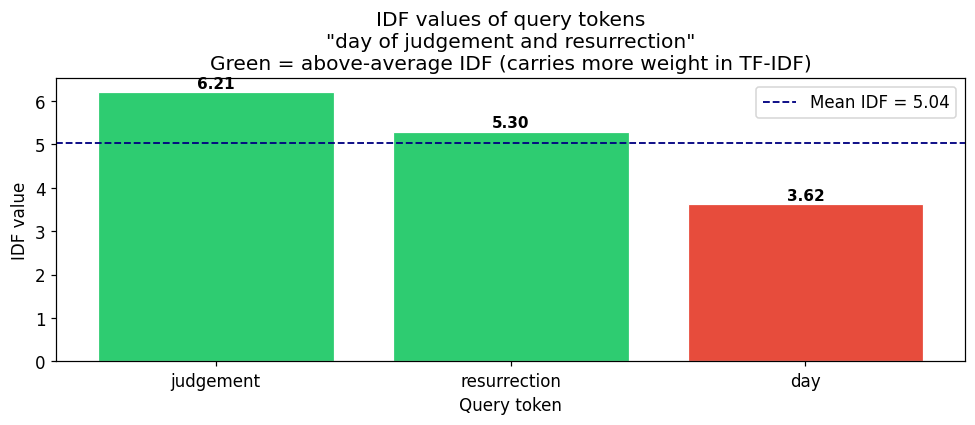


Interpretation:
  judgement            IDF=6.212  → HIGH weight
  resurrection         IDF=5.296  → HIGH weight
  day                  IDF=3.618  → low weight


In [140]:
# ── Cell 6.2: Bar chart — IDF values of query words ──────────────────────────
# This shows WHICH query words carry the most weight in TF-IDF scoring.

query_tokens = preprocess(COMPARISON_QUERY)
print(f'Query tokens after preprocessing: {query_tokens}')

# Get IDF for each query token
token_idf_pairs = []
for token in query_tokens:
    if token in tfidf_vectorizer.vocabulary_:
        idx = tfidf_vectorizer.vocabulary_[token]
        idf_val = tfidf_vectorizer.idf_[idx]
        token_idf_pairs.append((token, idf_val))
    else:
        token_idf_pairs.append((token, 0.0))  # out-of-vocab
        print(f'  Note: "{token}" not in TF-IDF vocabulary (filtered out)')

token_idf_pairs.sort(key=lambda x: x[1], reverse=True)
tokens_sorted, idfs_sorted = zip(*token_idf_pairs)

fig, ax = plt.subplots(figsize=(9, 4))

bar_colors = ['#2ecc71' if v >= np.mean(idfs_sorted) else '#e74c3c' for v in idfs_sorted]
bars = ax.bar(tokens_sorted, idfs_sorted, color=bar_colors, edgecolor='white', linewidth=0.8)

# Annotate each bar
for bar, idf_val in zip(bars, idfs_sorted):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{idf_val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(np.mean(idfs_sorted), color='navy', linestyle='--', linewidth=1.2,
           label=f'Mean IDF = {np.mean(idfs_sorted):.2f}')
ax.set_xlabel('Query token')
ax.set_ylabel('IDF value')
ax.set_title(f'IDF values of query tokens\n"{COMPARISON_QUERY}"\nGreen = above-average IDF (carries more weight in TF-IDF)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nInterpretation:')
for t, v in token_idf_pairs:
    weight = 'HIGH weight' if v > np.mean(idfs_sorted) else 'low weight'
    print(f'  {t:<20} IDF={v:.3f}  → {weight}')

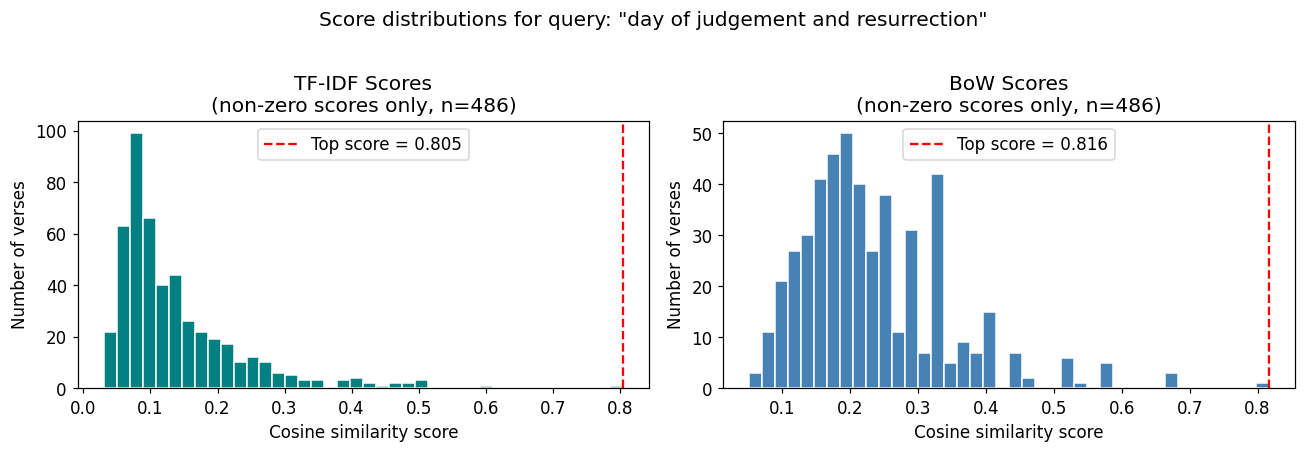

TF-IDF produces a more spread-out distribution — it discriminates better.
BoW tends to cluster scores together because common words inflate all scores.


In [141]:
# ── Cell 6.3: Score distribution comparison — violin or box plot ──────────────
# Compare how TF-IDF vs BoW distribute their similarity scores across all verses.

processed_q = ' '.join(preprocess(COMPARISON_QUERY))

# TF-IDF scores for ALL verses
tfidf_q_vec = tfidf_vectorizer.transform([processed_q])
tfidf_all_scores = cosine_similarity(tfidf_q_vec, tfidf_matrix).flatten()

# BoW scores for ALL verses
bow_q_vec = bow_vectorizer.transform([processed_q])
bow_all_scores = cosine_similarity(bow_q_vec, bow_matrix).flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, scores, title, color in [
    (axes[0], tfidf_all_scores, 'TF-IDF Scores', 'teal'),
    (axes[1], bow_all_scores,  'BoW Scores',    'steelblue')
]:
    # Only show non-zero scores for clarity
    nonzero_scores = scores[scores > 0]
    ax.hist(nonzero_scores, bins=40, color=color, edgecolor='white')
    ax.set_title(f'{title}\n(non-zero scores only, n={len(nonzero_scores)})')
    ax.set_xlabel('Cosine similarity score')
    ax.set_ylabel('Number of verses')
    top_score = scores.max()
    ax.axvline(top_score, color='red', linestyle='--', label=f'Top score = {top_score:.3f}')
    ax.legend()

plt.suptitle(f'Score distributions for query: "{COMPARISON_QUERY}"', y=1.02)
plt.tight_layout()
plt.show()

print('TF-IDF produces a more spread-out distribution — it discriminates better.')
print('BoW tends to cluster scores together because common words inflate all scores.')

---
## Section 7: Inspecting TF-IDF Vectors

Let's look inside a single verse's TF-IDF vector and compare it with its BoW representation.

In [142]:
# ── Cell 7.1: Top TF-IDF scoring words in one verse ──────────────────────────

# Pick a verse with a decent number of content words
# Find a verse of moderate length (15-30 tokens after preprocessing)
moderate_verses = df[df['processed'].apply(len).between(15, 30)]
inspect_idx = moderate_verses.index[0]  # use the first match

print(f'Inspecting Verse: Surah {df.loc[inspect_idx, "Surah"]}, Verse {df.loc[inspect_idx, "Verse"]}')
print(f'\nOriginal text:')
print(f'  "{df.loc[inspect_idx, "sahih"]}"')
print(f'\nProcessed tokens ({len(df.loc[inspect_idx, "processed"])} tokens):')
print(f'  {df.loc[inspect_idx, "processed"]}')

# TF-IDF vector for this verse
tfidf_vocab = tfidf_vectorizer.get_feature_names_out()
tfidf_row = tfidf_matrix[inspect_idx].toarray().flatten()

# Get top 10 by TF-IDF score
top10_tfidf_idx = tfidf_row.argsort()[::-1][:10]
top10_tfidf = [(tfidf_vocab[i], tfidf_row[i]) for i in top10_tfidf_idx if tfidf_row[i] > 0]

print(f'\nTop 10 words by TF-IDF score:')
print(f'{"Word":<20} {"TF-IDF score"}')
print('-' * 35)
for word, score in top10_tfidf:
    bar = '█' * int(score * 50)
    print(f'{word:<20} {score:.5f}  {bar}')

Inspecting Verse: Surah 2, Verse 19

Original text:
  "Or [it is] like a rainstorm from the sky within which is darkness, thunder and lightning. They put their fingers in their ears against the thunderclaps in dread of death. But Allah is encompassing of the disbelievers."

Processed tokens (16 tokens):
  ['like', 'rainstorm', 'sky', 'within', 'darkness', 'thunder', 'lightning', 'put', 'fingers', 'ears', 'thunderclaps', 'dread', 'death', 'allah', 'encompassing', 'disbelievers']

Top 10 words by TF-IDF score:
Word                 TF-IDF score
-----------------------------------
thunder              0.35023  █████████████████
fingers              0.35023  █████████████████
dread                0.35023  █████████████████
lightning            0.33857  ████████████████
encompassing         0.30143  ███████████████
ears                 0.28779  ██████████████
darkness             0.28499  ██████████████
put                  0.22618  ███████████
sky                  0.22618  ███████████
death

In [143]:
# ── Cell 7.2: Compare BoW top words vs TF-IDF top words ──────────────────────

# BoW vector for the same verse
bow_vocab = bow_vectorizer.get_feature_names_out()
bow_row = bow_matrix[inspect_idx].toarray().flatten()

top10_bow_idx = bow_row.argsort()[::-1][:10]
top10_bow = [(bow_vocab[i], int(bow_row[i])) for i in top10_bow_idx if bow_row[i] > 0]

print('BoW top 10 words (by raw count):')
print(f'{"Word":<20} {"Count"}')
print('-' * 30)
for word, count in top10_bow:
    bar = '█' * count
    print(f'{word:<20} {count}  {bar}')

print()
print('TF-IDF top 10 words (by weighted importance):')
print(f'{"Word":<20} {"TF-IDF"}')
print('-' * 35)
for word, score in top10_tfidf:
    bar = '█' * int(score * 50)
    print(f'{word:<20} {score:.5f}  {bar}')

# Find words that appear in BoW top10 but not TF-IDF top10
bow_set   = {w for w, _ in top10_bow}
tfidf_set = {w for w, _ in top10_tfidf}

demoted = bow_set - tfidf_set
promoted = tfidf_set - bow_set

print(f'\nWords DEMOTED by TF-IDF (were in BoW top10, now gone): {demoted}')
print(f'Words PROMOTED by TF-IDF (not in BoW top10, now appear): {promoted}')
print('\nTF-IDF promotes DISTINCTIVE words, BoW promotes FREQUENT words.')

BoW top 10 words (by raw count):
Word                 Count
------------------------------
lightning            1  █
within               1  █
thunder              1  █
put                  1  █
like                 1  █
sky                  1  █
fingers              1  █
encompassing         1  █
ears                 1  █
dread                1  █

TF-IDF top 10 words (by weighted importance):
Word                 TF-IDF
-----------------------------------
thunder              0.35023  █████████████████
fingers              0.35023  █████████████████
dread                0.35023  █████████████████
lightning            0.33857  ████████████████
encompassing         0.30143  ███████████████
ears                 0.28779  ██████████████
darkness             0.28499  ██████████████
put                  0.22618  ███████████
sky                  0.22618  ███████████
death                0.21515  ██████████

Words DEMOTED by TF-IDF (were in BoW top10, now gone): {'within', 'like'}
Words PROMO

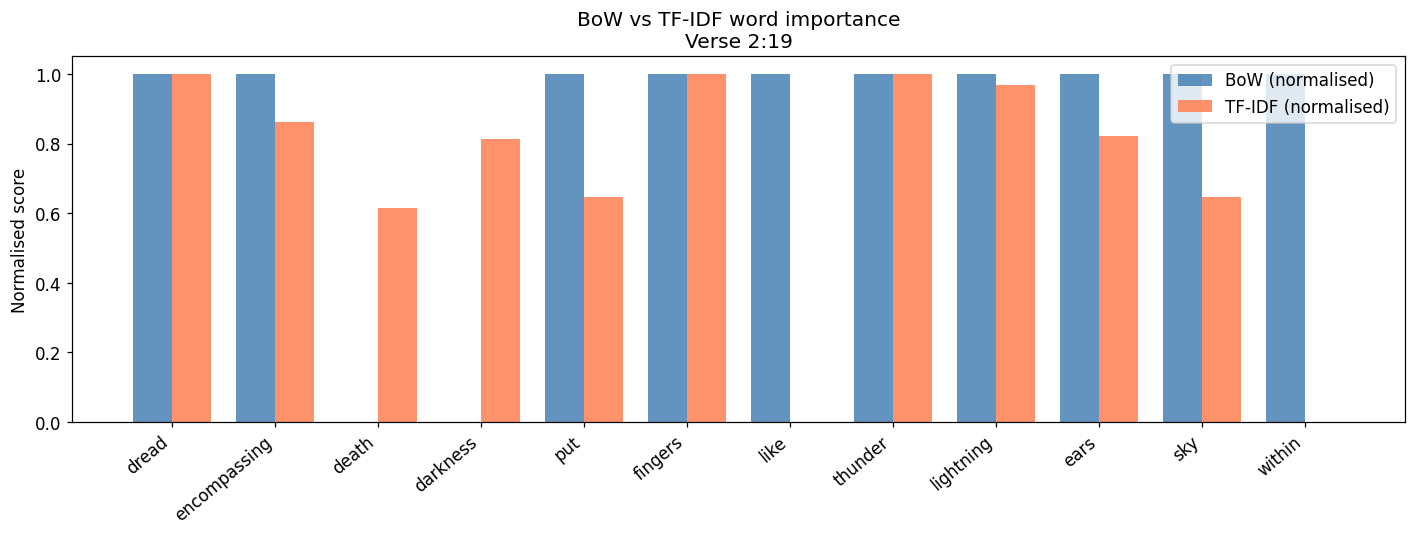

Words where the bars are very different show the biggest re-ranking effect.


In [144]:
# ── Cell 7.3: Side-by-side bar chart of BoW vs TF-IDF word importance ─────────

# Collect all words from either top-10 list
all_words = list(set([w for w, _ in top10_bow] + [w for w, _ in top10_tfidf]))

# Get normalised BoW scores (divide by max for fair comparison)
bow_dict = {w: c for w, c in top10_bow}
tfidf_dict = {w: s for w, s in top10_tfidf}

# Extend with zeros for missing words
bow_vals_plot   = [bow_dict.get(w, 0) for w in all_words]
tfidf_vals_plot = [tfidf_dict.get(w, 0.0) for w in all_words]

# Normalise BoW to [0,1] for visual comparison
bmax = max(bow_vals_plot) if max(bow_vals_plot) > 0 else 1
norm_bow = [v / bmax for v in bow_vals_plot]
tmax = max(tfidf_vals_plot) if max(tfidf_vals_plot) > 0 else 1
norm_tfidf = [v / tmax for v in tfidf_vals_plot]

x = np.arange(len(all_words))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
bars1 = ax.bar(x - width/2, norm_bow,   width, label='BoW (normalised)',    color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, norm_tfidf, width, label='TF-IDF (normalised)', color='coral',     alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(all_words, rotation=40, ha='right')
ax.set_ylabel('Normalised score')
ax.set_title(f'BoW vs TF-IDF word importance\nVerse {df.loc[inspect_idx, "Surah"]}:{df.loc[inspect_idx, "Verse"]}')
ax.legend()
plt.tight_layout()
plt.show()

print('Words where the bars are very different show the biggest re-ranking effect.')

---
## Section 8: Limitations of TF-IDF

### 8.1 What TF-IDF Cannot Do

TF-IDF is a major improvement over Bag-of-Words, but it still has fundamental limitations:

#### 1. No Semantic Understanding
TF-IDF is **purely statistical**. It knows nothing about meaning. The words `"kindness"` and `"mercy"` are treated as completely unrelated terms even though they express similar concepts. A query for `"kindness to parents"` will fail to retrieve verses about `"mercy towards parents"` unless the exact word `"kindness"` appears.

#### 2. No Word Order
Like BoW, TF-IDF treats a document as a **set of weighted terms**. The sentences:
- *"Allah forgives the believers"*
- *"The believers forgive Allah"* (theologically strange, but illustrative)

would produce identical TF-IDF vectors. Context and grammar are lost.

#### 3. Sparsity
The TF-IDF matrix has 6,236 × 5,000 = 31 million cells, yet only ~0.6% are non-zero. Most verses share very few exact words. This makes nearest-neighbour search expensive for very large corpora.

#### 4. Corpus Bias in IDF
IDF is a **global corpus statistic**. In the Quran, `"allah"` has a very low IDF — not because the concept is unimportant, but because the text mentions it constantly. If we added a million Wikipedia articles to the corpus, `"allah"` would gain a higher IDF simply because most Wikipedia articles do not mention it. The IDF value depends entirely on what other documents are in your collection.

#### 5. Vocabulary Mismatch
If a user queries a word that was filtered out (appears in fewer than `min_df=2` verses), TF-IDF returns nothing for that term. Out-of-vocabulary words are silently ignored.

In [145]:
# ── Cell 8.1: Failure demo — semantic gap ─────────────────────────────────────
# Query: "kindness to parents"
# Expected: verses about being merciful, respectful, or dutiful to parents
# Actual: only retrieves verses that contain the exact word 'kindness'

FAILURE_QUERY = 'kindness to parents'

print('=' * 70)
print(f'Failure Demo: TF-IDF for "{FAILURE_QUERY}"')
print('=' * 70)

processed_fail = preprocess(FAILURE_QUERY)
print(f'Preprocessed query tokens: {processed_fail}')
print()

# Check which query words survive preprocessing and are in vocabulary
for token in processed_fail:
    if token in tfidf_vectorizer.vocabulary_:
        idx = tfidf_vectorizer.vocabulary_[token]
        idf = tfidf_vectorizer.idf_[idx]
        print(f'  "{token}" → in vocabulary, IDF = {idf:.4f}')
    else:
        print(f'  "{token}" → NOT in TF-IDF vocabulary (filtered out)')

print()
results_fail = tfidf_search(FAILURE_QUERY, tfidf_vectorizer, tfidf_matrix, df)
for _, row in results_fail.iterrows():
    print(f"  [{row['Rank']}] {int(row['Surah'])}:{int(row['Verse'])}  score={row['Score']:.5f}")
    print(f"       {row['Text'][:110]}")
    print()

print('-' * 70)
print('Compare with a SEMANTIC query that should retrieve the same verses:')
print('Query: "mercy to parents" — note: TF-IDF still cannot bridge the gap')
print('between "kindness" and "mercy". Only word embeddings can do that.')

Failure Demo: TF-IDF for "kindness to parents"
Preprocessed query tokens: ['kindness', 'parents']

  "kindness" → in vocabulary, IDF = 7.9465
  "parents" → in vocabulary, IDF = 6.6028

  Preprocessed query: "kindness parents"
  [1] 14:41  score=0.30170
       Our Lord, forgive me and my parents and the believers the Day the account is established."

  [2] 19:14  score=0.29277
       And dutiful to his parents, and he was not a disobedient tyrant.

  [3] 4:5  score=0.28613
       And do not give the weak-minded your property, which Allah has made a means of sustenance for you, but provide

  [4] 18:80  score=0.26543
       And as for the boy, his parents were believers, and we feared that he would overburden them by transgression a

  [5] 31:15  score=0.25807
       But if they endeavor to make you associate with Me that of which you have no knowledge, do not obey them but a

----------------------------------------------------------------------
Compare with a SEMANTIC query that should

In [146]:
# ── Cell 8.2: Show corpus bias in IDF ────────────────────────────────────────
# Demonstrate that IDF is a corpus statistic, not a measure of conceptual importance.

print('IDF values in the Quran corpus vs conceptual importance:')
print()
print(f'{"Word":<25} {"IDF in Quran corpus":<25} {"Comment"}')
print('-' * 75)

important_words = {
    'allah': 'Theologically central — but low IDF because everywhere',
    'prophet': 'Important concept — moderate IDF',
    'pray': 'Core practice — check IDF',
    'resurrection': 'Key theological event — high IDF (few verses)',
    'camel': 'Mentioned rarely — very high IDF',
    'mercy': 'Core attribute — moderate IDF',
}

for word, comment in important_words.items():
    if word in tfidf_vectorizer.vocabulary_:
        idx = tfidf_vectorizer.vocabulary_[word]
        idf = tfidf_vectorizer.idf_[idx]
        print(f'{word:<25} {idf:<25.4f} {comment}')
    else:
        print(f'{word:<25} {"(not in vocab)":<25} {comment}')

print()
print('Key takeaway: Low IDF ≠ Unimportant. It just means the word is common')
print('IN THIS CORPUS. Add a million news articles, and IDF values shift completely.')

IDF values in the Quran corpus vs conceptual importance:

Word                      IDF in Quran corpus       Comment
---------------------------------------------------------------------------
allah                     2.1264                    Theologically central — but low IDF because everywhere
prophet                   5.4342                    Important concept — moderate IDF
pray                      7.5410                    Core practice — check IDF
resurrection              5.2956                    Key theological event — high IDF (few verses)
camel                     8.6396                    Mentioned rarely — very high IDF
mercy                     4.7684                    Core attribute — moderate IDF

Key takeaway: Low IDF ≠ Unimportant. It just means the word is common
IN THIS CORPUS. Add a million news articles, and IDF values shift completely.


---
## Section 9: Student Reflection Questions

These questions are designed to test your understanding of the concepts covered in this notebook. Attempt them before reading the hints.

---

### Question 1
**Why does the word `"allah"` receive a LOW TF-IDF score in the Quran corpus, even though it is theologically the most central word in the text?**

*Think about:* What is IDF measuring? What does it mean for a word to appear in nearly every verse?

*Hint:* IDF = log(N / df). If df ≈ N (word appears in almost every document), then IDF → log(1) → 0.

---

### Question 2
**Suppose we combined the Quran corpus with 1 million English news articles. How would the IDF values of the following words change, and why?**

| Word | IDF in Quran only | IDF after adding news | Direction |
|---|---|---|---|
| `allah` | low | ? | |
| `president` | very high (rare) | ? | |
| `the` | filtered out | ? | |
| `resurrection` | high | ? | |

*Think about:* The news articles would contain `"president"` constantly but almost never `"resurrection"` or `"allah"`.

---

### Question 3
**Why does `sublinear_tf=True` (which uses log(1+tf) instead of raw tf) help for long documents?**

Consider two verses:
- Verse A: 10 words, `"mercy"` appears 2 times → raw TF = 0.20
- Verse B: 100 words, `"mercy"` appears 10 times → raw TF = 0.10

With `sublinear_tf`:
- Verse A: log(1+2) = 1.099 → normalised TF = 1.099/10 ≈ 0.110
- Verse B: log(1+10) = 2.398 → normalised TF = 2.398/100 ≈ 0.024

Does using log dampen the difference between counting 2 vs 10 times? Is this desirable?

---

### Question 4
**Find a query where TF-IDF clearly outperforms BoW in your opinion. Run both searches in the code cell below and explain WHY TF-IDF gives better results for that specific query.**

*Hint:* Try queries with a mix of common and rare words. Queries like `"fire and brimstone"`, `"honey and milk"`, or `"patience of the righteous"` might show interesting differences.

In [147]:
# ── Cell 9.4 (Student exercise): Compare BoW vs TF-IDF for YOUR chosen query ──

# TODO: Replace this query with one you think will show a clear difference
STUDENT_QUERY = 'fire and punishment'  # <-- change this

print(f'Student query: "{STUDENT_QUERY}"')
print(f'Preprocessed: {preprocess(STUDENT_QUERY)}')
print()

print('TF-IDF results:')
tfidf_student = tfidf_search(STUDENT_QUERY, tfidf_vectorizer, tfidf_matrix, df)
for _, r in tfidf_student.iterrows():
    print(f"  [{r['Rank']}] {int(r['Surah'])}:{int(r['Verse'])} (s={r['Score']:.4f}) | {r['Text'][:80]}...")

print()
print('BoW results:')
bow_student = bow_search(STUDENT_QUERY, bow_vectorizer, bow_matrix, df)
for r in bow_student:
    print(f"  [{r['idx']}] {r['Surah']}:{r['Verse']} (s={r['score']:.4f}) | {r['text'][:80]}")

print()
print('--- Write your analysis below ---')
print('# Which method gives better results? Why?')
print('# Which query words have high IDF? Which have low IDF?')

Student query: "fire and punishment"
Preprocessed: ['fire', 'punishment']

TF-IDF results:
  Preprocessed query: "fire punishment"
  [1] 8:14 (s=0.6213) | "That [is yours], so taste it." And indeed for the disbelievers is the punishmen...
  [2] 51:13 (s=0.6065) | [It is] the Day they will be tormented over the Fire...
  [3] 15:50 (s=0.4975) | And that it is My punishment which is the painful punishment....
  [4] 104:6 (s=0.4702) | It is the fire of Allah, [eternally] fueled,...
  [5] 59:3 (s=0.4281) | And if not that Allah had decreed for them evacuation, He would have punished th...

BoW results:
  [1851] 15:50 (s=0.6325) | And that it is My punishment which is the painful punishment....
  [1173] 8:14 (s=0.6325) | "That [is yours], so taste it." And indeed for the disbelievers is the punishmen
  [5918] 85:10 (s=0.5477) | Indeed, those who have tortured the believing men and believing women and then h
  [3522] 32:20 (s=0.5145) | But as for those who defiantly disobeyed, their refuge is

### Question 5
**What does TF-IDF still NOT solve?**

List at least three things that TF-IDF cannot do, even with perfect implementation. For each, explain how word embeddings (covered in NB05) would address it.

| Problem | TF-IDF limitation | How embeddings help |
|---|---|---|
| Synonyms | `"mercy"` ≠ `"kindness"` — different tokens | Embeddings place synonyms close in vector space |
| Word order | `"God forgives man"` = `"Man forgives God"` | Sentence embeddings encode order |
| Context | `"bank"` (river) = `"bank"` (finance) | Contextualised embeddings (BERT) differ per context |
| ? | ... | ... |
| ? | ... | ... |

---

*These questions will be discussed in the next workshop session.*

---
## Section 10: Summary and What's Next

### What We Covered in This Notebook

| Topic | Key Concept | Code |
|---|---|---|
| BoW limitations | Equal weighting problem | `CountVectorizer`, `Counter` |
| Term Frequency | count(t,d) / len(d) | Manual Python implementation |
| Inverse Document Frequency | log(N / df(t)) | Manual Python + sklearn |
| TF-IDF score | TF × IDF | `TfidfVectorizer` |
| Sparsity | 99%+ zeros | `.nnz`, `.shape` |
| Ranked retrieval | TF-IDF + cosine similarity | `cosine_similarity` |
| BoW vs TF-IDF | Side-by-side comparison | Bar charts, result tables |
| Corpus bias | IDF depends on what's in the corpus | Analysis of `"allah"` IDF |
| Semantic gap | `"kindness"` ≠ `"mercy"` for TF-IDF | Failure demo |

---

### The Journey So Far

```
  NB01: Preprocessing + BoW
    "Turn words into counts"
         ↓
  NB02: TF-IDF  ← WE ARE HERE
    "Weight counts by rarity"
         ↓
  NB03: N-Grams (coming up)
    "Capture short word sequences"
         ↓
  NB05: Word Embeddings
    "Give words meaning through context"
```

### Preview: Notebook 3 — N-Grams and Context

TF-IDF has solved the weighting problem but still treats every word independently. What about **phrases**?

- `"not merciful"` vs `"merciful"` are treated the same (after stopword removal)!
- `"day of judgement"` is a semantic unit, not three separate words

In **NB03**, we will explore **N-grams** — sequences of N consecutive words — and how they capture local context that single words miss. We will build bigram and trigram models and see how they change our search results.

In [148]:
# ── Cell 10.1: Final summary statistics ──────────────────────────────────────

print('=' * 60)
print('NB02 — TF-IDF and Ranked Retrieval')
print('Final Summary Statistics')
print('=' * 60)
print(f'  Dataset      : Quran — sahih translation')
print(f'  Total verses : {len(df):,}')
print(f'  Vocabulary   : {len(tfidf_vectorizer.vocabulary_):,} terms (after min_df=2, max=5000)')
print(f'  Matrix shape : {tfidf_matrix.shape}')
print(f'  Sparsity     : {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0]*tfidf_matrix.shape[1])):.2%}')
print()
print('  Highest IDF (most distinctive) words:')
top5_idf = idf_df.head(5)
for _, row in top5_idf.iterrows():
    print(f'    {row["word"]:<20} IDF = {row["idf"]:.4f}')
print()
print('  Lowest IDF (most common) words:')
bottom5_idf = idf_df.tail(5)
for _, row in bottom5_idf.iterrows():
    print(f'    {row["word"]:<20} IDF = {row["idf"]:.4f}')
print()
print('  Next up: NB03 — N-Grams and Context Windows')
print('=' * 60)

NB02 — TF-IDF and Ranked Retrieval
Final Summary Statistics
  Dataset      : Quran — sahih translation
  Total verses : 6,236
  Vocabulary   : 3,240 terms (after min_df=2, max=5000)
  Matrix shape : (6236, 3240)
  Sparsity     : 99.72%

  Highest IDF (most distinctive) words:
    absence              IDF = 8.6396
    abused               IDF = 8.6396
    accordingly          IDF = 8.6396
    lands                IDF = 8.6396
    lighten              IDF = 8.6396

  Lowest IDF (most common) words:
    people               IDF = 3.2415
    said                 IDF = 3.1521
    lord                 IDF = 2.9744
    indeed               IDF = 2.5135
    allah                IDF = 2.1264

  Next up: NB03 — N-Grams and Context Windows
